# UAV / Drone Detection and Tracking
## YOLOv8n + Kalman Filter + Hungarian Matching

This cleaned notebook keeps the original implementation intact and organizes it into a clear execution flow:

1. Environment setup and imports
2. YOLOv8n model loading and evaluation
3. Detection metrics and visualizations
4. Tracking setup and Kalman-based tracker
5. Tracking logs, metrics, plots, trajectories, and video export
6. Optional single-image inference
7. Optional unseen-video inference and tracking

> **Note:** Only run the optional unseen-video cells when the video path exists.


---
# 1. Environment Setup
## Mount Google Drive and Install Dependencies


In [73]:
# ─────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# Install required packages
import subprocess
subprocess.run(['pip', 'install', '-q', 'ultralytics', 'supervision',
                'seaborn', 'matplotlib', 'opencv-python-headless'], check=True)

print("Dependencies installed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dependencies installed.


---
# 2. Imports, Paths, and Model Loading


In [74]:
!pip install ultralytics -q

import os, glob, re, shutil, cv2, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from IPython.display import Video, display
from ultralytics import YOLO

WORK_DIR = "/content/uav_project"
os.makedirs(WORK_DIR, exist_ok=True)

DATA_YAML = "/content/drive/MyDrive/New_Global_Split_v2/data.yaml"
BEST_PT = "/content/drive/MyDrive/YOLO_Models/uav_yolov8n_ep50_optimized/best.pt"

device = 0  # use GPU
IMG_SIZE = 640
BATCH = 8

CLASS_NAMES = {0: "drone"}

assert os.path.exists(BEST_PT), "Saved model not found."
assert os.path.exists(DATA_YAML), "data.yaml not found."

model = YOLO(BEST_PT)
print("Final model loaded:", BEST_PT)

Final model loaded: /content/drive/MyDrive/YOLO_Models/uav_yolov8n_ep50_optimized/best.pt


---
# 3. YOLOv8n Detection Evaluation
## Validation and Test Metrics


In [75]:
def print_metrics(name, results):
    mp = results.box.mp
    mr = results.box.mr
    map50 = results.box.map50
    map95 = results.box.map
    f1 = 2 * mp * mr / (mp + mr + 1e-9)

    print(f"\n📊 {name} Metrics")
    print(f"Precision : {mp:.4f}")
    print(f"Recall    : {mr:.4f}")
    print(f"mAP@0.50  : {map50:.4f}")
    print(f"mAP@50-95 : {map95:.4f}")
    print(f"F1 Score  : {f1:.4f}")

In [76]:
device = 'cpu'

val_results = model.val(
    data=DATA_YAML,
    split="val",
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=device,
    conf=0.25,
    iou=0.45,
    plots=True,
    project=WORK_DIR,
    name="val_final",
    exist_ok=True
)

test_results = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=device,
    conf=0.25,
    iou=0.45,
    plots=True,
    project=WORK_DIR,
    name="test_final",
    exist_ok=True
)

print_metrics("Validation", val_results)
print_metrics("Test", test_results)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 1.4±1.5 ms, read: 15.3±5.0 MB/s, size: 112.8 KB)
val: Scanning /content/drive/MyDrive/New_Global_Split_v2/val/labels.cache... 1050 images, 395 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1050/1050 209.7Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 46, len(boxes) = 701. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 132/132 2.3s/it 5:08
                   all       1050        701      0.922      0.816      0.813      0.439
Speed: 6.2ms preprocess, 257.8ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /co

---
# 4. Detection Training Dashboard


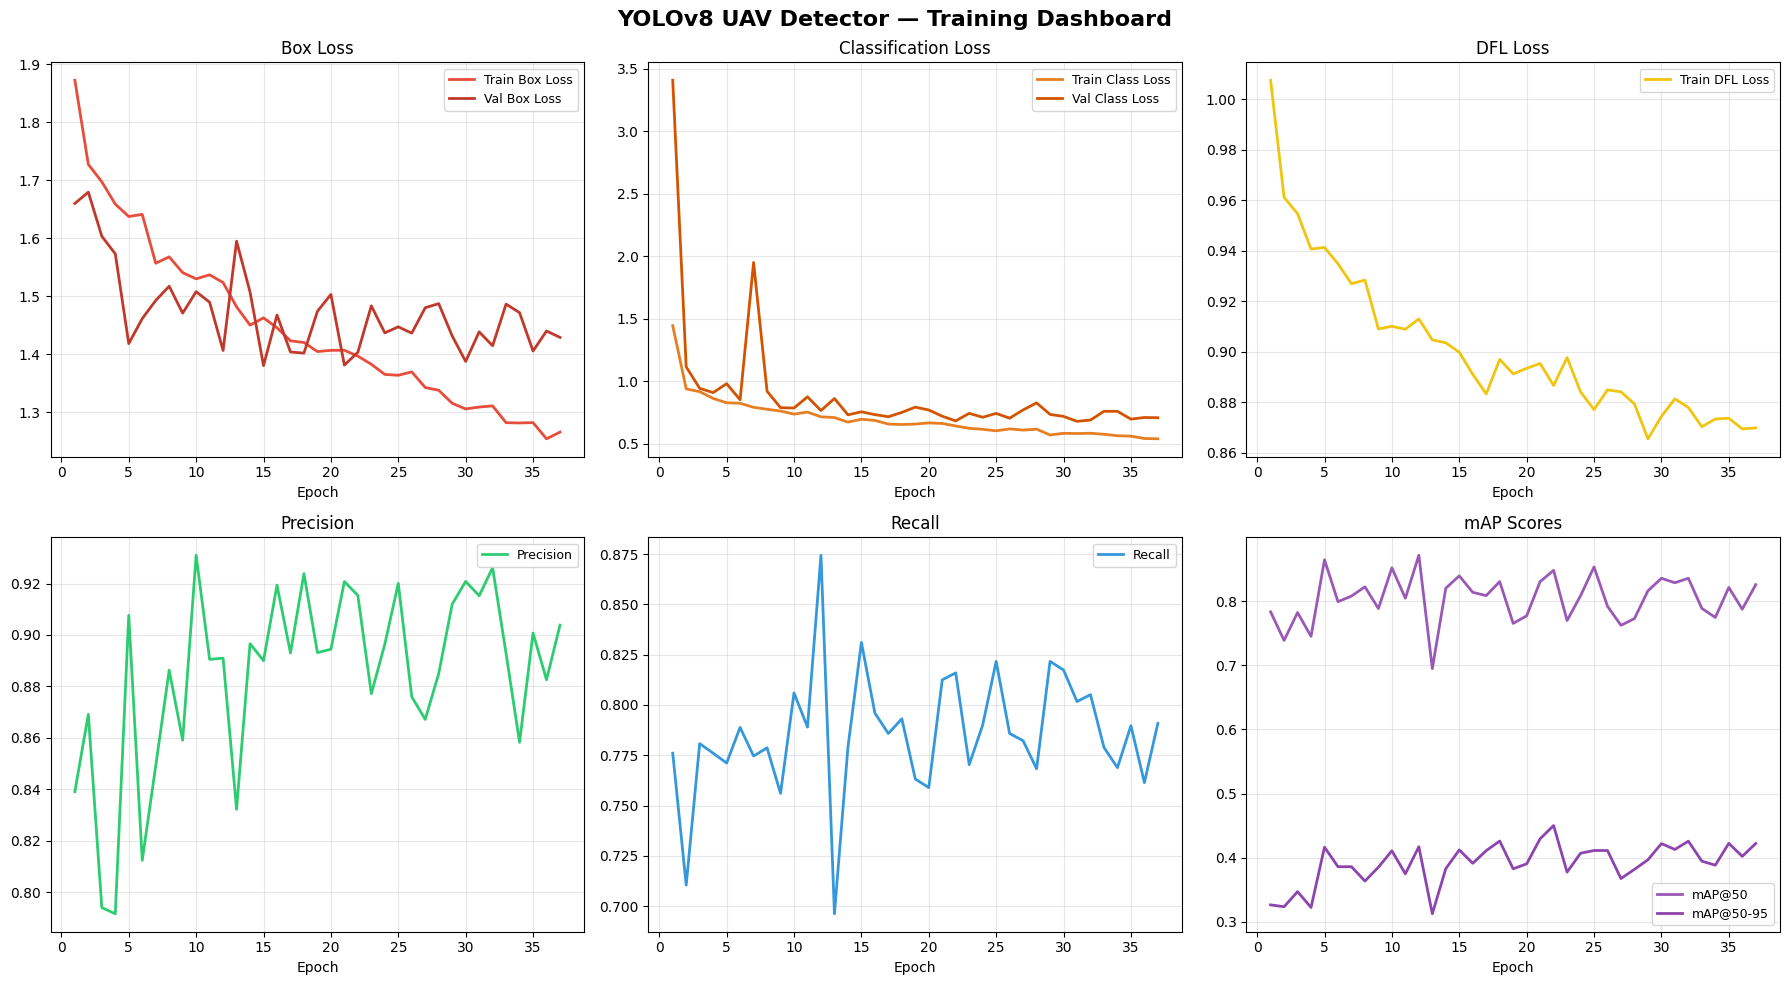

Dashboard saved: /content/uav_project/training_dashboard.png


In [77]:
# ─────────────────────────────────────────────
def load_training_csv(train_dir):
    csv_path = os.path.join(train_dir, 'results.csv')
    if not os.path.isfile(csv_path):
        return None
    import pandas as pd
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    return df

# Path to saved training results
TRAIN_RESULTS_DIR = "/content/drive/MyDrive/YOLO_Models/uav_yolov8n_ep50_optimized/train_results"

try:
    import pandas as pd

    df = load_training_csv(TRAIN_RESULTS_DIR)

    if df is not None:
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle('YOLOv8 UAV Detector — Training Dashboard', fontsize=16, fontweight='bold')

        cols_map = {
            'train/box_loss': ('Train Box Loss',    axes[0, 0], '#E74C3C'),
            'train/cls_loss': ('Train Class Loss',  axes[0, 1], '#E67E22'),
            'train/dfl_loss': ('Train DFL Loss',    axes[0, 2], '#F1C40F'),
            'val/box_loss':   ('Val Box Loss',      axes[0, 0], '#C0392B'),
            'val/cls_loss':   ('Val Class Loss',    axes[0, 1], '#D35400'),
            'metrics/precision(B)': ('Precision',  axes[1, 0], '#2ECC71'),
            'metrics/recall(B)':    ('Recall',     axes[1, 1], '#3498DB'),
            'metrics/mAP50(B)':     ('mAP@50',     axes[1, 2], '#9B59B6'),
            'metrics/mAP50-95(B)':  ('mAP@50-95',  axes[1, 2], '#8E44AD'),
        }

        for col, (label, ax, color) in cols_map.items():
            if col in df.columns:
                ax.plot(df['epoch'], df[col], label=label, color=color, linewidth=2)
                ax.set_xlabel('Epoch')
                ax.legend(fontsize=9)
                ax.grid(True, alpha=0.3)

        axes[0, 0].set_title('Box Loss')
        axes[0, 1].set_title('Classification Loss')
        axes[0, 2].set_title('DFL Loss')
        axes[1, 0].set_title('Precision')
        axes[1, 1].set_title('Recall')
        axes[1, 2].set_title('mAP Scores')

        plt.tight_layout()

        dashboard_path = os.path.join(WORK_DIR, 'training_dashboard.png')
        plt.savefig(dashboard_path, dpi=150, bbox_inches='tight')

        plt.show()
        print("Dashboard saved:", dashboard_path)

    else:
        print("results.csv not found — skipping dashboard")

except Exception as e:
    print(f"Dashboard skipped: {e}")

---
# 5. Detection Metrics Summary Table


In [78]:
# ─────────────────────────────────────────────
# Extract metrics
mp, mr, map50, map50_95 = (
    val_results.box.mp,
    val_results.box.mr,
    val_results.box.map50,
    val_results.box.map,
)

tp_mp, tp_mr, tp_map50, tp_map50_95 = (
    test_results.box.mp,
    test_results.box.mr,
    test_results.box.map50,
    test_results.box.map,
)

# ─────────────────────────────────────────────
# Build table
metrics_data = {
    'Split': ['Validation', 'Test'],
    'Precision':  [f'{mp:.4f}',       f'{tp_mp:.4f}'],
    'Recall':     [f'{mr:.4f}',       f'{tp_mr:.4f}'],
    'mAP@0.50':   [f'{map50:.4f}',    f'{tp_map50:.4f}'],
    'mAP@0.5:0.95':[f'{map50_95:.4f}', f'{tp_map50_95:.4f}'],
    'F1': [
        f'{2*mp*mr/(mp+mr+1e-9):.4f}',
        f'{2*tp_mp*tp_mr/(tp_mp+tp_mr+1e-9):.4f}'
    ],
}

# ─────────────────────────────────────────────
# Display nicely
try:
    import pandas as pd
    tbl = pd.DataFrame(metrics_data).set_index('Split')

    print("\n" + "="*60)
    print("  FINAL METRIC SUMMARY")
    print("="*60)
    print(tbl.to_string())
    print("="*60)

except:
    print(metrics_data)


  FINAL METRIC SUMMARY
           Precision  Recall mAP@0.50 mAP@0.5:0.95      F1
Split                                                     
Validation    0.9220  0.8160   0.8131       0.4392  0.8657
Test          0.9385  0.9305   0.9171       0.4787  0.9345


---
# 6. Test-Set Confusion Matrix


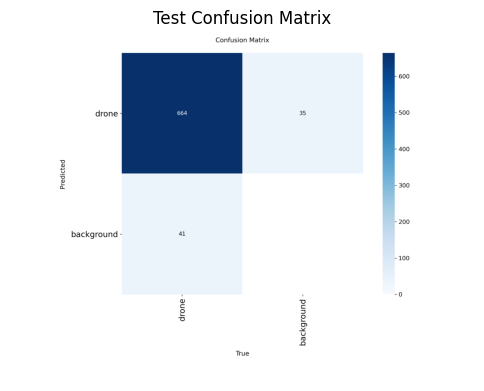

In [81]:
import matplotlib.pyplot as plt
import cv2
import os

# Path to already-generated confusion matrix
cm_path = os.path.join(WORK_DIR, "test_final", "confusion_matrix.png")

if not os.path.exists(cm_path):
    print("⚠️ Confusion matrix not found. Run evaluation cell first.")
else:
    img = cv2.imread(cm_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title("Test Confusion Matrix")
    plt.axis('off')
    plt.show()

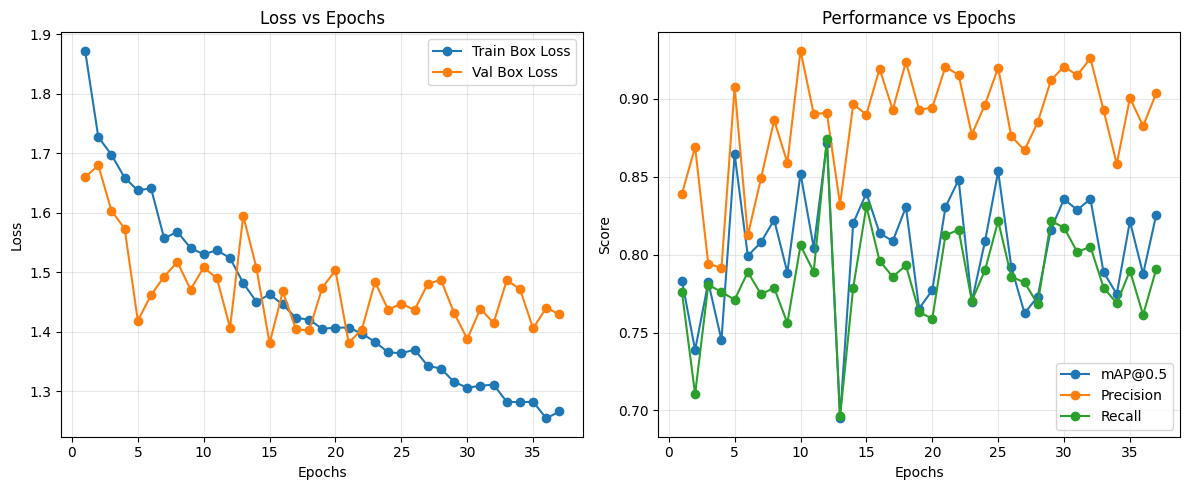

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to your YOLO results.csv
csv_path = "/content/drive/MyDrive/YOLO_Models/uav_yolov8n_ep50_optimized/train_results/results.csv"

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

epochs = df['epoch']

# =========================
# 1) LOSS CURVE
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, df['train/box_loss'], marker='o', label='Train Box Loss')
plt.plot(epochs, df['val/box_loss'], marker='o', label='Val Box Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.grid(alpha=0.3)

# =========================
# 2) PERFORMANCE CURVE (instead of accuracy)
# =========================
plt.subplot(1,2,2)
plt.plot(epochs, df['metrics/mAP50(B)'], marker='o', label='mAP@0.5')
plt.plot(epochs, df['metrics/precision(B)'], marker='o', label='Precision')
plt.plot(epochs, df['metrics/recall(B)'], marker='o', label='Recall')

plt.xlabel("Epochs")
plt.ylabel("Score")
plt.title("Performance vs Epochs")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/custom_training_curves.png", dpi=300)
plt.show()

---
# 7. Test-Set Visual Prediction Samples


In [13]:
model.predict(
    source="/content/drive/MyDrive/New_Global_Split_v2/test/images",
    conf=0.25,
    iou=0.45,
    max_det=3,
    imgsz=640,
    device=device,
    save=True,
    save_txt=True,
    save_conf=True,
    project=WORK_DIR,
    name="test_predictions_final",
    exist_ok=True,
    verbose=False
)

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /content/uav_project/test_predictions_final
691 labels saved to /content/uav_project/test_predictions_final/labels


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'drone'}
 obb: None
 orig_img: array([[[220,  79,  58],
         [220,  79,  58],
         [220,  79,  58],
         ...,
         [255, 119,  93],
         [255, 119,  93],
         [255, 119,  93]],
 
        [[222,  79,  58],
         [222,  79,  58],
         [222,  79,  58],
         ...,
         [252, 116,  90],
         [252, 116,  90],
         [252, 116,  90]],
 
        [[222,  77,  56],
         [222,  77,  56],
         [223,  76,  56],
         ...,
         [250, 113,  87],
         [250, 113,  87],
         [250, 113,  87]],
 
        ...,
 
        [[ 68,  84,  83],
         [ 73,  89,  88],
         [ 73,  89,  88],
         ...,
         [ 51,  88,  78],
         [ 64, 101,  91],
         [ 42,  82,  71]],
 
        [[ 71,  87,  86],
         [ 81,  97,  96],
         [ 69,  85,  84],
         ...,
         [ 47,  87,

In [14]:
pred_path = os.path.join(WORK_DIR, "test_predictions_final")
images = glob.glob(f"{pred_path}/*.jpg")

print("Prediction images:", len(images))
samples = random.sample(images, min(20, len(images)))

plt.figure(figsize=(20, 15))

for i, img_path in enumerate(samples):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(4, 5, i+1)
    plt.imshow(img)
    plt.title(f"{i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

---
# 8. Tracking Setup
## Choose Drone Sequence and Output Directory


In [147]:
import os, glob, re, shutil
from pathlib import Path

# ==============================
# Edit only these two lines
# ==============================
DRONE_NAME = "drone12"
SRC_DIR = "/content/drive/MyDrive/Senior Project/Video/Test/Drone/Drone_12/Images"

# Output sequential tracking folder
OUT_SEQ_DIR = Path(f"/content/drive/MyDrive/Tracking_Test/{DRONE_NAME}_from_split_test")
OUT_SEQ_DIR.mkdir(parents=True, exist_ok=True)

def natural_key(path):
    return [int(t) if t.isdigit() else t.lower()
            for t in re.split(r"(\d+)", os.path.basename(path))]

# Load source frames
frames = sorted(
    glob.glob(os.path.join(SRC_DIR, "*.jpg")) +
    glob.glob(os.path.join(SRC_DIR, "*.jpeg")) +
    glob.glob(os.path.join(SRC_DIR, "*.png")),
    key=natural_key
)

print(f"{DRONE_NAME} source frames:", len(frames))
assert len(frames) > 0, "No frames found. Check SRC_DIR."

# Clear old tracking sequence
for f in OUT_SEQ_DIR.glob("*"):
    if f.is_file():
        f.unlink()

# Copy frames with clean sequential names
for i, src in enumerate(frames, start=1):
    src_path = Path(src)
    dst = OUT_SEQ_DIR / f"frame_{i:05d}{src_path.suffix.lower()}"
    shutil.copy(src_path, dst)

print(f"{DRONE_NAME} tracking sequence created")
print("Folder:", OUT_SEQ_DIR)
print("Frames copied:", len(list(OUT_SEQ_DIR.glob("*"))))

drone12 source frames: 600
drone12 tracking sequence created
Folder: /content/drive/MyDrive/Tracking_Test/drone12_from_split_test
Frames copied: 600


In [148]:
# ==============================
# Choose drone here
# ==============================
USE_DRONE = "drone12"  # change freely: drone2, drone3, drone6, drone4, etc.

# ==============================
# Auto-generate paths
# ==============================
BASE_SEQ_DIR = "/content/drive/MyDrive/Tracking_Test"

TRACK_SEQ_DIR = os.path.join(BASE_SEQ_DIR, f"{USE_DRONE}_from_split_test")
TRACKER_OUTPUT_DIR = os.path.join(WORK_DIR, f"tracker_output_{USE_DRONE}_final")
VIDEO_NAME = f"tracked_uav_{USE_DRONE}_final.mp4"

# ==============================
# Checks
# ==============================
print("Tracking:", USE_DRONE)
print("Input:", TRACK_SEQ_DIR)
print("Output:", TRACKER_OUTPUT_DIR)

assert os.path.exists(TRACK_SEQ_DIR), f"Sequence folder not found: {TRACK_SEQ_DIR}"

Tracking: drone12
Input: /content/drive/MyDrive/Tracking_Test/drone12_from_split_test
Output: /content/uav_project/tracker_output_drone12_final


---
# 9. Kalman-Based UAV Tracker
## YOLOv8 Detections + 8D Kalman State + IoU/Center-Distance Hungarian Matching


In [149]:
# ─────────────────────────────────────────────────────────────
"""
KalmanUAVTracker
────────────────
State vector : [cx, cy, w, h, vx, vy, vw, vh]  (8-D)

Updates in this version:
• IoU + center-distance association
• cleaner labels
• clipped boxes
• better for small UAVs
"""
# ─────────────────────────────────────────────────────────────

import numpy as np
import cv2
from scipy.optimize import linear_sum_assignment
from ultralytics import YOLO


# ── IoU helper ────────────────────────────────────────────────
def iou_batch(bboxes_a: np.ndarray, bboxes_b: np.ndarray) -> np.ndarray:
    """Vectorised IoU  (N×4, M×4) → N×M  |  format: [cx,cy,w,h]"""
    if len(bboxes_a) == 0 or len(bboxes_b) == 0:
        return np.zeros((len(bboxes_a), len(bboxes_b)), dtype=np.float32)

    ax1 = bboxes_a[:, 0:1] - bboxes_a[:, 2:3] / 2
    ay1 = bboxes_a[:, 1:2] - bboxes_a[:, 3:4] / 2
    ax2 = ax1 + bboxes_a[:, 2:3]
    ay2 = ay1 + bboxes_a[:, 3:4]

    bx1 = bboxes_b[:, 0] - bboxes_b[:, 2] / 2
    by1 = bboxes_b[:, 1] - bboxes_b[:, 3] / 2
    bx2 = bx1 + bboxes_b[:, 2]
    by2 = by1 + bboxes_b[:, 3]

    inter_x1 = np.maximum(ax1, bx1)
    inter_y1 = np.maximum(ay1, by1)
    inter_x2 = np.minimum(ax2, bx2)
    inter_y2 = np.minimum(ay2, by2)

    inter = np.maximum(0, inter_x2 - inter_x1) * np.maximum(0, inter_y2 - inter_y1)
    area_a = bboxes_a[:, 2:3] * bboxes_a[:, 3:4]
    area_b = bboxes_b[:, 2] * bboxes_b[:, 3]
    union = area_a + area_b - inter + 1e-9

    return inter / union


# ── Single Track ──────────────────────────────────────────────
class KalmanTrack:
    """
    Constant-velocity Kalman filter for one UAV bounding box.
    State  : [cx, cy, w, h, vx, vy, vw, vh]
    Measure: [cx, cy, w, h]
    """
    _count = 0

    def __init__(self, bbox: np.ndarray, class_id: int = 0):
        KalmanTrack._count += 1
        self.id = KalmanTrack._count
        self.class_id = class_id
        self.hits = 1
        self.no_update = 0
        self.age = 1
        self.history = []

        dt = 1.0

        # State transition matrix F
        self.F = np.eye(8, dtype=np.float32)
        for i in range(4):
            self.F[i, i + 4] = dt

        # Measurement matrix H
        self.H = np.zeros((4, 8), dtype=np.float32)
        for i in range(4):
            self.H[i, i] = 1.0

        # Process noise Q
        self.Q = np.eye(8, dtype=np.float32)
        self.Q[:4, :4] *= 0.05
        self.Q[4:, 4:] *= 0.01

        # Measurement noise R
        self.R = np.eye(4, dtype=np.float32) * 1.0

        # Error covariance P
        self.P = np.eye(8, dtype=np.float32) * 10.0
        self.P[4:, 4:] *= 100.0

        # Initial state x
        self.x = np.zeros((8, 1), dtype=np.float32)
        self.x[:4, 0] = bbox

    def predict(self) -> np.ndarray:
        """Predict next bbox state."""
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        self.age += 1
        self.no_update += 1
        self.history.append(self.x[:4, 0].copy())
        return self.x[:4, 0]

    def update(self, bbox: np.ndarray):
        """Update with detected bbox."""
        z = bbox.reshape(4, 1).astype(np.float32)

        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)

        self.x = self.x + K @ y

        I = np.eye(8, dtype=np.float32)
        self.P = (I - K @ self.H) @ self.P

        self.hits += 1
        self.no_update = 0

    @property
    def bbox(self) -> np.ndarray:
        return self.x[:4, 0]

    @property
    def bbox_xyxy(self) -> np.ndarray:
        cx, cy, w, h = self.x[:4, 0]
        return np.array([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2])

    @property
    def velocity(self) -> np.ndarray:
        return self.x[4:6, 0]


# ── Multi-Object Tracker ──────────────────────────────────────
class UAVTracker:
    """
    Multi-object UAV tracker combining:
      • YOLOv8 detection
      • Kalman filter state estimation
      • Hungarian algorithm association
      • IoU + center-distance matching
    """

    def __init__(
        self,
        det_model_path: str,
        conf_threshold: float = 0.30,
        iou_threshold: float = 0.45,
        max_age: int = 40,
        min_hits: int = 4,
        iou_assoc_thr: float = 0.30,
        distance_weight: float = 0.40,
        max_center_dist: float = 80.0,
        device: str = "cuda",
    ):
        self.model = YOLO(det_model_path)
        self.conf = conf_threshold
        self.iou = iou_threshold
        self.max_age = max_age
        self.min_hits = min_hits
        self.iou_assoc_thr = iou_assoc_thr
        self.distance_weight = distance_weight
        self.max_center_dist = max_center_dist
        self.device = device

        self.tracks: list[KalmanTrack] = []
        self.frame_count = 0
        KalmanTrack._count = 0

    # ── Run YOLO on a frame
    def _detect(self, frame: np.ndarray) -> np.ndarray:
        """Returns (N, 6): [cx, cy, w, h, conf, class_id]."""
        results = self.model(
            frame,
            conf=self.conf,
            iou=self.iou,
            device=self.device,
            verbose=False
        )[0]

        if results.boxes is None or len(results.boxes) == 0:
            return np.empty((0, 6), dtype=np.float32)

        boxes = results.boxes.xywh.cpu().numpy()
        confs = results.boxes.conf.cpu().numpy().reshape(-1, 1)
        cls_ids = results.boxes.cls.cpu().numpy().reshape(-1, 1)

        return np.hstack([boxes, confs, cls_ids]).astype(np.float32)

    # ── Hungarian assignment
    def _associate(self, tracks: list, detections: np.ndarray):
        if len(tracks) == 0:
            return [], list(range(len(detections))), []

        if len(detections) == 0:
            return [], [], list(range(len(tracks)))

        trk_bboxes = np.array([t.bbox for t in tracks])
        det_bboxes = detections[:, :4]

        # IoU score
        iou_mat = iou_batch(trk_bboxes, det_bboxes)

        # Center-distance score
        trk_centers = trk_bboxes[:, :2]
        det_centers = det_bboxes[:, :2]

        dist_mat = np.linalg.norm(
            trk_centers[:, None, :] - det_centers[None, :, :],
            axis=2
        )

        dist_score = np.clip(1.0 - (dist_mat / self.max_center_dist), 0, 1)

        # Combined score
        iou_weight = 1.0 - self.distance_weight
        score_mat = (iou_weight * iou_mat) + (self.distance_weight * dist_score)

        cost_mat = 1.0 - score_mat
        row_ind, col_ind = linear_sum_assignment(cost_mat)

        matched = []

        for r, c in zip(row_ind, col_ind):
            if score_mat[r, c] >= self.iou_assoc_thr:
                matched.append((r, c))

        matched_trk = {r for r, _ in matched}
        matched_det = {c for _, c in matched}

        unm_trk = [i for i in range(len(tracks)) if i not in matched_trk]
        unm_det = [i for i in range(len(detections)) if i not in matched_det]

        return matched, unm_det, unm_trk

    # ── Main update function
    def update(self, frame: np.ndarray) -> list:
        self.frame_count += 1

        detections = self._detect(frame)

        for t in self.tracks:
            t.predict()

        matched, unm_det, unm_trk = self._associate(self.tracks, detections)

        # Update matched tracks
        for trk_idx, det_idx in matched:
            self.tracks[trk_idx].update(detections[det_idx, :4])
            self.tracks[trk_idx].class_id = int(detections[det_idx, 5])

        # Create new tracks
        for det_idx in unm_det:
            new_trk = KalmanTrack(
                detections[det_idx, :4],
                class_id=int(detections[det_idx, 5])
            )
            self.tracks.append(new_trk)

        # Remove dead tracks
        self.tracks = [t for t in self.tracks if t.no_update <= self.max_age]

        # Return confirmed tracks only
        output = []

        for t in self.tracks:
            if t.hits >= self.min_hits or self.frame_count <= self.min_hits:
                output.append({
                    "id": t.id,
                    "bbox_xyxy": t.bbox_xyxy,
                    "conf": t.hits / (t.age + 1e-9),
                    "class_id": t.class_id,
                    "hits": t.hits,
                    "velocity": t.velocity,
                })

        return output

    def reset(self):
        self.tracks = []
        self.frame_count = 0
        KalmanTrack._count = 0


# ── Colour palette for track IDs ──────────────────────────────
_PALETTE = [
    (0, 255, 0),
    (0, 127, 255),
    (255, 0, 0),
    (255, 200, 0),
    (200, 0, 255),
    (0, 255, 200),
    (255, 100, 100),
    (100, 255, 100),
]

def track_color(tid: int):
    return _PALETTE[tid % len(_PALETTE)]


# ── Draw one frame ────────────────────────────────────────────
def draw_tracks(frame: np.ndarray, tracks: list, class_names: dict) -> np.ndarray:
    vis = frame.copy()
    H, W = vis.shape[:2]

    for t in tracks:
        x1, y1, x2, y2 = t["bbox_xyxy"].astype(int)

        # Clip to frame
        x1 = max(0, min(W - 1, x1))
        y1 = max(0, min(H - 1, y1))
        x2 = max(0, min(W - 1, x2))
        y2 = max(0, min(H - 1, y2))

        tid = t["id"]
        cname = class_names.get(t["class_id"], f"cls{t['class_id']}")
        color = track_color(tid)

        # Cleaner label
        label = f"ID:{tid} {cname}"

        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)

        (tw, th), _ = cv2.getTextSize(
            label,
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            1
        )

        label_y1 = max(0, y1 - th - 8)
        label_y2 = max(th + 8, y1)

        cv2.rectangle(
            vis,
            (x1, label_y1),
            (min(W - 1, x1 + tw + 4), label_y2),
            color,
            -1
        )

        cv2.putText(
            vis,
            label,
            (x1 + 2, label_y2 - 4),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (0, 0, 0),
            1,
            cv2.LINE_AA
        )

    return vis

---
# 10. Tracking Loop with CSV Logging


In [150]:
import time
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import os, glob, cv2, shutil

def run_tracking_with_logs(
    frame_list,
    tracker,
    output_dir,
    class_names,
    use_drone="drone",
    save_frames=True
):
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir, exist_ok=True)

    tracking_rows = []
    frame_summary_rows = []
    track_stats = defaultdict(list)

    start_time = time.time()
    processed_frames = 0

    for frame_idx, img_path in enumerate(frame_list):
        frame = cv2.imread(img_path)
        if frame is None:
            continue

        tracks = tracker.update(frame)
        processed_frames += 1

        # Log every confirmed track in this frame
        for t in tracks:
            x1, y1, x2, y2 = t["bbox_xyxy"]
            vx, vy = t["velocity"]

            tracking_rows.append({
                "frame_idx": frame_idx,
                "frame_file": os.path.basename(img_path),
                "track_id": int(t["id"]),
                "class_id": int(t["class_id"]),
                "class_name": class_names.get(int(t["class_id"]), "unknown"),
                "x1": float(x1),
                "y1": float(y1),
                "x2": float(x2),
                "y2": float(y2),
                "cx": float((x1 + x2) / 2),
                "cy": float((y1 + y2) / 2),
                "w": float(x2 - x1),
                "h": float(y2 - y1),
                "track_conf_proxy": float(t["conf"]),
                "hits": int(t["hits"]),
                "vx": float(vx),
                "vy": float(vy),
                "speed_px_per_frame": float((vx**2 + vy**2) ** 0.5),
            })

            track_stats[int(t["id"])].append(np.array([x1, y1, x2, y2], dtype=float))

        frame_summary_rows.append({
            "frame_idx": frame_idx,
            "frame_file": os.path.basename(img_path),
            "num_active_tracks": len(tracks),
        })

        if save_frames:
            vis = draw_tracks(frame, tracks, class_names)
            out_path = os.path.join(output_dir, f"frame_{frame_idx:05d}.jpg")
            cv2.imwrite(out_path, vis)

        if frame_idx % 50 == 0:
            print(f"Processed {frame_idx}/{len(frame_list)} | active tracks: {len(tracks)}")

    elapsed = time.time() - start_time
    fps = processed_frames / elapsed if elapsed > 0 else 0

    tracking_df = pd.DataFrame(tracking_rows)
    frame_summary_df = pd.DataFrame(frame_summary_rows)

    tracking_csv = os.path.join(output_dir, f"tracking_log_{use_drone}.csv")
    frame_csv = os.path.join(output_dir, f"frame_summary_{use_drone}.csv")

    tracking_df.to_csv(tracking_csv, index=False)
    frame_summary_df.to_csv(frame_csv, index=False)

    print("\nTracking complete")
    print("Processed frames:", processed_frames)
    print("Elapsed time:", round(elapsed, 2), "sec")
    print("FPS:", round(fps, 2))
    print("Tracking log saved:", tracking_csv)
    print("Frame summary saved:", frame_csv)

    return tracking_df, frame_summary_df, track_stats, fps

---
# 11. Run Tracker on Ordered Test Frames


In [151]:
if os.path.exists(TRACKER_OUTPUT_DIR):
    shutil.rmtree(TRACKER_OUTPUT_DIR)
os.makedirs(TRACKER_OUTPUT_DIR, exist_ok=True)

def natural_key(path):
    return [int(t) if t.isdigit() else t.lower()
            for t in re.split(r"(\d+)", os.path.basename(path))]

frame_list = sorted(
    glob.glob(os.path.join(TRACK_SEQ_DIR, "*.jpg")) +
    glob.glob(os.path.join(TRACK_SEQ_DIR, "*.jpeg")) +
    glob.glob(os.path.join(TRACK_SEQ_DIR, "*.png")),
    key=natural_key
)

print("Total frames:", len(frame_list))
assert len(frame_list) > 0, "No tracking frames found."

tracker = UAVTracker(
    det_model_path=BEST_PT,
    conf_threshold=0.38,
    iou_threshold=0.45,
    max_age=40,
    min_hits=5,
    iou_assoc_thr=0.30,
    distance_weight=0.40,
    max_center_dist=80.0,
    device=device,
)

tracking_df, frame_summary_df, track_stats, tracking_fps = run_tracking_with_logs(
    frame_list=frame_list,
    tracker=tracker,
    output_dir=TRACKER_OUTPUT_DIR,
    class_names=CLASS_NAMES,
    use_drone=USE_DRONE,
    save_frames=True
)

track_stats = defaultdict(list)

for processed, img_path in enumerate(frame_list):
    frame = cv2.imread(img_path)

    if frame is None:
        continue

    tracks = tracker.update(frame)

    for t in tracks:
        track_stats[t["id"]].append(t["bbox_xyxy"].copy())

    vis = draw_tracks(frame, tracks, CLASS_NAMES)

    out_path = os.path.join(TRACKER_OUTPUT_DIR, f"frame_{processed:05d}.jpg")
    cv2.imwrite(out_path, vis)

    if processed % 50 == 0:
        print(f"Processed {processed} | active tracks: {len(tracks)}")

print("\n Tracking complete")
print("Frames processed:", len(frame_list))
print("Unique tracks created:", KalmanTrack._count)
print("Stable tracks:", len(track_stats))

Total frames: 600
Processed 0/600 | active tracks: 2
Processed 50/600 | active tracks: 2
Processed 100/600 | active tracks: 2
Processed 150/600 | active tracks: 2
Processed 200/600 | active tracks: 1
Processed 250/600 | active tracks: 1
Processed 300/600 | active tracks: 1
Processed 350/600 | active tracks: 0
Processed 400/600 | active tracks: 0
Processed 450/600 | active tracks: 0
Processed 500/600 | active tracks: 0
Processed 550/600 | active tracks: 0

Tracking complete
Processed frames: 600
Elapsed time: 150.81 sec
FPS: 3.98
Tracking log saved: /content/uav_project/tracker_output_drone12_final/tracking_log_drone12.csv
Frame summary saved: /content/uav_project/tracker_output_drone12_final/frame_summary_drone12.csv
Processed 0 | active tracks: 0
Processed 50 | active tracks: 2
Processed 100 | active tracks: 2
Processed 150 | active tracks: 2
Processed 200 | active tracks: 1
Processed 250 | active tracks: 1
Processed 300 | active tracks: 1
Processed 350 | active tracks: 0
Processed 40

---
# 16. Export Tracked Frames as Video


In [152]:
frames_for_video = sorted(
    glob.glob(os.path.join(TRACKER_OUTPUT_DIR, "*.jpg")),
    key=natural_key
)

print("Frames for video:", len(frames_for_video))
assert len(frames_for_video) > 0, "No tracking frames found."

sample = cv2.imread(frames_for_video[0])
h, w = sample.shape[:2]

OUTPUT_VIDEO = os.path.join(WORK_DIR, VIDEO_NAME)

writer = cv2.VideoWriter(
    OUTPUT_VIDEO,
    cv2.VideoWriter_fourcc(*"mp4v"),
    30,
    (w, h)
)

for fp in frames_for_video:
    frame = cv2.imread(fp)
    if frame is not None:
        writer.write(frame)

writer.release()

print("Video saved:", OUTPUT_VIDEO)
display(Video(OUTPUT_VIDEO, embed=True, width=700))

Output hidden; open in https://colab.research.google.com to view.

---
# 12. Tracking Metrics Summary


In [153]:
def summarize_tracking(tracking_df, frame_summary_df, fps, output_dir, use_drone="drone"):
    if tracking_df.empty:
        summary = {
            "sequence": use_drone,
            "total_frames": len(frame_summary_df),
            "frames_with_tracks": 0,
            "total_unique_tracks": 0,
            "average_track_length_frames": 0,
            "longest_track_frames": 0,
            "shortest_track_frames": 0,
            "average_active_tracks_per_frame": frame_summary_df["num_active_tracks"].mean()
                if not frame_summary_df.empty else 0,
            "fps": fps,
        }
    else:
        track_lengths = tracking_df.groupby("track_id")["frame_idx"].nunique()
        frames_with_tracks = tracking_df["frame_idx"].nunique()

        summary = {
            "sequence": use_drone,
            "total_frames": len(frame_summary_df),
            "frames_with_tracks": int(frames_with_tracks),
            "total_unique_tracks": int(tracking_df["track_id"].nunique()),
            "average_track_length_frames": float(track_lengths.mean()),
            "longest_track_frames": int(track_lengths.max()),
            "shortest_track_frames": int(track_lengths.min()),
            "average_active_tracks_per_frame": float(frame_summary_df["num_active_tracks"].mean()),
            "max_active_tracks_per_frame": int(frame_summary_df["num_active_tracks"].max()),
            "mean_speed_px_per_frame": float(tracking_df["speed_px_per_frame"].mean()),
            "max_speed_px_per_frame": float(tracking_df["speed_px_per_frame"].max()),
            "fps": float(fps),
        }

    summary_df = pd.DataFrame([summary])
    summary_csv = os.path.join(output_dir, f"tracking_summary_{use_drone}.csv")
    summary_df.to_csv(summary_csv, index=False)

    display(summary_df)
    print("Tracking summary saved:", summary_csv)

    return summary_df

tracking_summary_df = summarize_tracking(
    tracking_df,
    frame_summary_df,
    tracking_fps,
    TRACKER_OUTPUT_DIR,
    USE_DRONE
)

,sequence,total_frames,frames_with_tracks,total_unique_tracks,average_track_length_frames,longest_track_frames,shortest_track_frames,average_active_tracks_per_frame,max_active_tracks_per_frame,mean_speed_px_per_frame,max_speed_px_per_frame,fps
0,drone12,600,332,2,259.0,332,186,0.863333,2,1.314287,3.714524,3.978562


Tracking summary saved: /content/uav_project/tracker_output_drone12_final/tracking_summary_drone12.csv


---
# 13. Tracking Plots
## Active Tracks, Track Lengths, and Speed


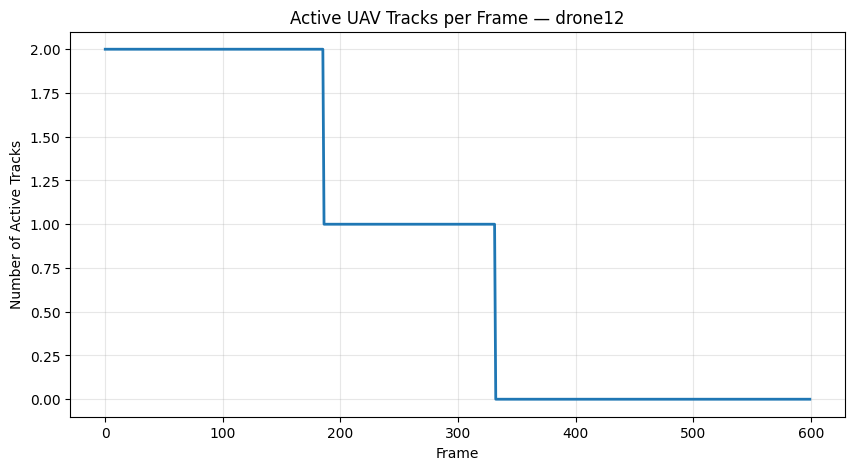

Saved: /content/uav_project/tracker_output_drone12_final/active_tracks_per_frame_drone12.png


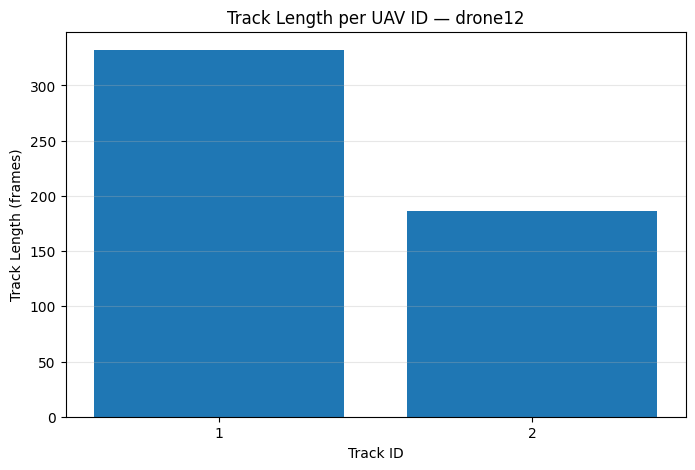

Saved: /content/uav_project/tracker_output_drone12_final/track_lengths_drone12.png


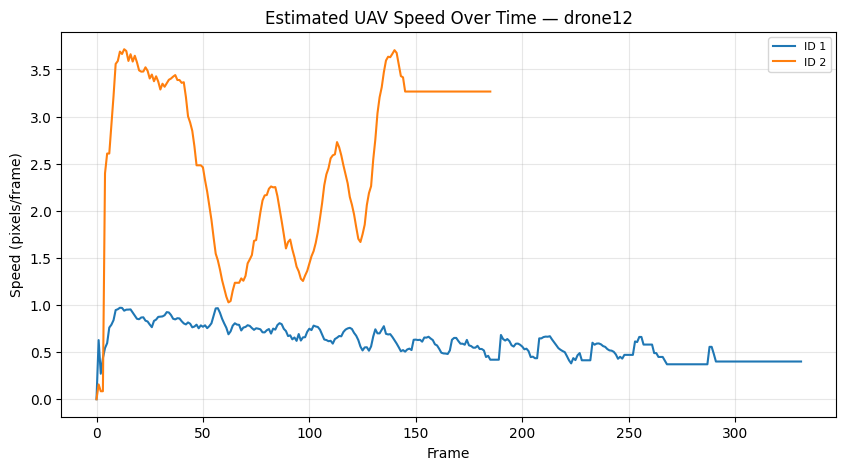

Saved: /content/uav_project/tracker_output_drone12_final/speed_over_time_drone12.png


In [154]:
# Plot 1: active tracks per frame
plt.figure(figsize=(10, 5))
plt.plot(frame_summary_df["frame_idx"], frame_summary_df["num_active_tracks"], linewidth=2)
plt.xlabel("Frame")
plt.ylabel("Number of Active Tracks")
plt.title(f"Active UAV Tracks per Frame — {USE_DRONE}")
plt.grid(alpha=0.3)
active_tracks_plot = os.path.join(TRACKER_OUTPUT_DIR, f"active_tracks_per_frame_{USE_DRONE}.png")
plt.savefig(active_tracks_plot, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", active_tracks_plot)


# Plot 2: track length distribution
if not tracking_df.empty:
    track_lengths = tracking_df.groupby("track_id")["frame_idx"].nunique()

    plt.figure(figsize=(8, 5))
    plt.bar(track_lengths.index.astype(str), track_lengths.values)
    plt.xlabel("Track ID")
    plt.ylabel("Track Length (frames)")
    plt.title(f"Track Length per UAV ID — {USE_DRONE}")
    plt.grid(axis="y", alpha=0.3)
    track_len_plot = os.path.join(TRACKER_OUTPUT_DIR, f"track_lengths_{USE_DRONE}.png")
    plt.savefig(track_len_plot, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", track_len_plot)


# Plot 3: speed over time
if not tracking_df.empty:
    plt.figure(figsize=(10, 5))
    for tid, group in tracking_df.groupby("track_id"):
        plt.plot(group["frame_idx"], group["speed_px_per_frame"], label=f"ID {tid}", linewidth=1.5)

    plt.xlabel("Frame")
    plt.ylabel("Speed (pixels/frame)")
    plt.title(f"Estimated UAV Speed Over Time — {USE_DRONE}")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)
    speed_plot = os.path.join(TRACKER_OUTPUT_DIR, f"speed_over_time_{USE_DRONE}.png")
    plt.savefig(speed_plot, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", speed_plot)

---
# 14. UAV Trajectory Visualization


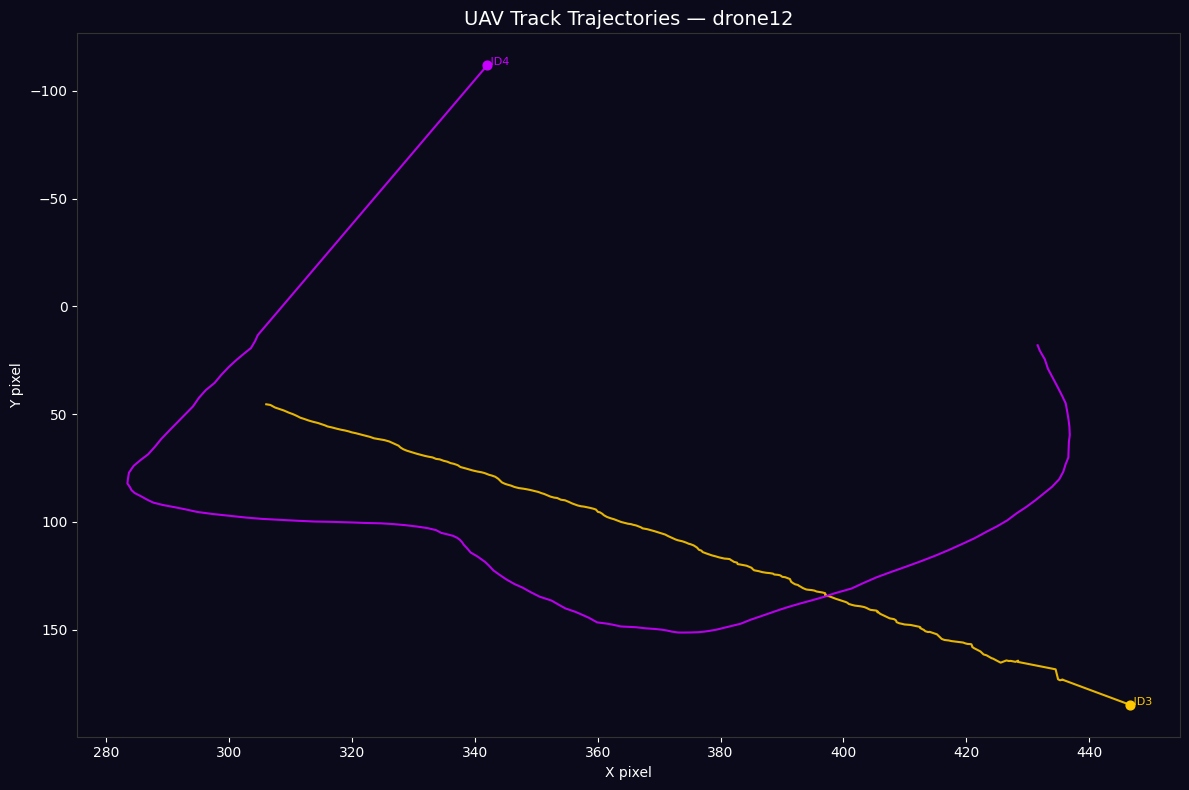

Trajectory saved: /content/uav_project/trajectories_drone12.png


In [155]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.set_facecolor("#0a0a1a")
fig.patch.set_facecolor("#0a0a1a")
ax.set_title(f"UAV Track Trajectories — {USE_DRONE}", color="white", fontsize=14)
ax.invert_yaxis()

for tid, bboxes in track_stats.items():
    if len(bboxes) < 3:
        continue

    bboxes = np.array(bboxes)
    cx = (bboxes[:, 0] + bboxes[:, 2]) / 2
    cy = (bboxes[:, 1] + bboxes[:, 3]) / 2

    c = np.array(track_color(tid)) / 255.0

    ax.plot(cx, cy, "-", color=c, linewidth=1.5, alpha=0.9)
    ax.scatter(cx[-1], cy[-1], color=c, s=40)
    ax.text(cx[-1], cy[-1], f" ID{tid}", color=c, fontsize=8)

ax.set_xlabel("X pixel", color="white")
ax.set_ylabel("Y pixel", color="white")
ax.tick_params(colors="white")

for spine in ax.spines.values():
    spine.set_edgecolor("#333")

traj_path = os.path.join(WORK_DIR, f"trajectories_{USE_DRONE}.png")
plt.tight_layout()
plt.savefig(traj_path, dpi=150, facecolor="#0a0a1a")
plt.show()

print("Trajectory saved:", traj_path)

---
# 15. Output File Inspection Utility


In [82]:
import os

BASE_DIR = "/content/uav_project"  # change if needed

def list_files(start_path, max_depth=3):
    for root, dirs, files in os.walk(start_path):
        level = root.replace(start_path, '').count(os.sep)
        if level > max_depth:
            continue
        indent = ' ' * 4 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f"{subindent}{f}")

list_files(BASE_DIR)

uav_project/
    tracked_uav_drone5_final.mp4
    tracked_uav_drone3_final.mp4
    trajectories_drone5.png
    trajectories_drone3.png
    confusion_matrix_custom.png
    trajectories_drone2.png
    tracked_uav_drone2_final.mp4
    trajectories_drone6.png
    single_infer.jpg
    tracked_uav_drone6_final.mp4
    training_dashboard.png
    unseen_video_clean/
        drone4_test_video.avi
        drone4_test_video.mp4
        labels/
            drone4_test_video_286.txt
            drone4_test_video_205.txt
            drone4_test_video_22.txt
            drone4_test_video_218.txt
            drone4_test_video_158.txt
            drone4_test_video_135.txt
            drone4_test_video_18.txt
            drone4_test_video_3.txt
            drone4_test_video_8.txt
            drone4_test_video_21.txt
            drone4_test_video_29.txt
            drone4_test_video_131.txt
            drone4_test_video_171.txt
            drone4_test_video_37.txt
            drone4_test_video_13.txt
   

---
# 15.1 Export Final Paper Figures
Copies the selected detection and tracking figures into a single `paper_final_figures` folder.


=== Detection Figures ===


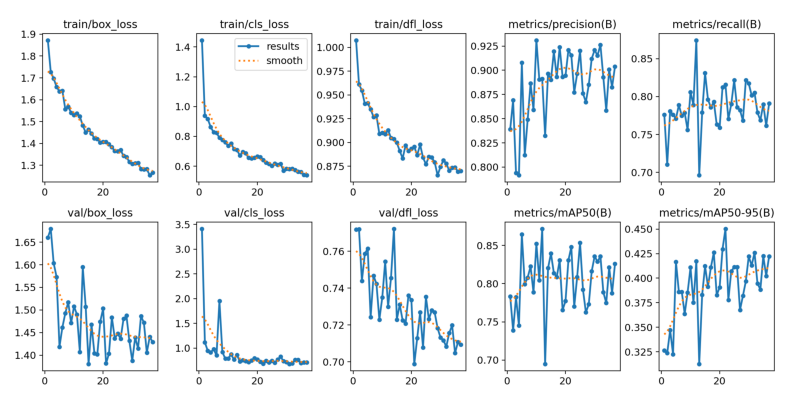

Saved: /content/drive/MyDrive/YOLO_Models/paper_final_figures/training_curves.png


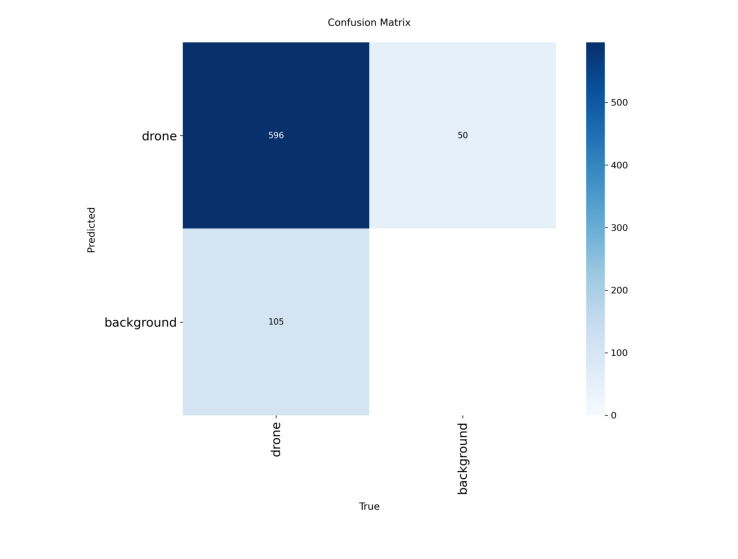

Saved: /content/drive/MyDrive/YOLO_Models/paper_final_figures/confusion_matrix.png


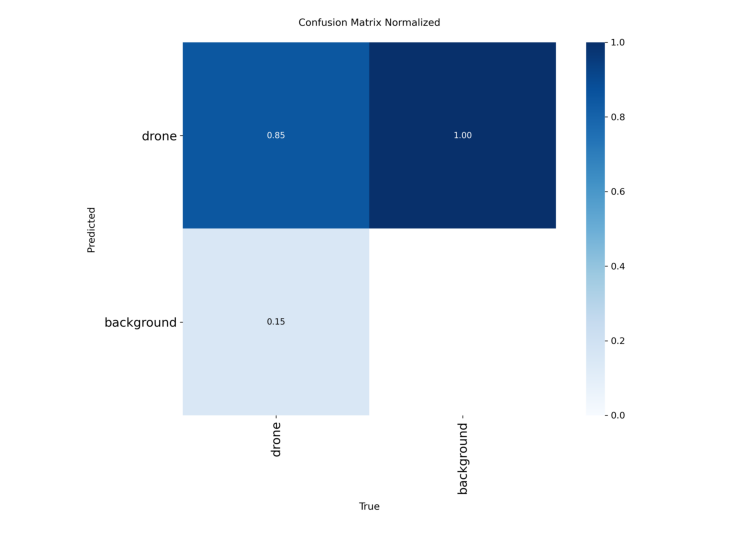

Saved: /content/drive/MyDrive/YOLO_Models/paper_final_figures/confusion_matrix_normalized.png


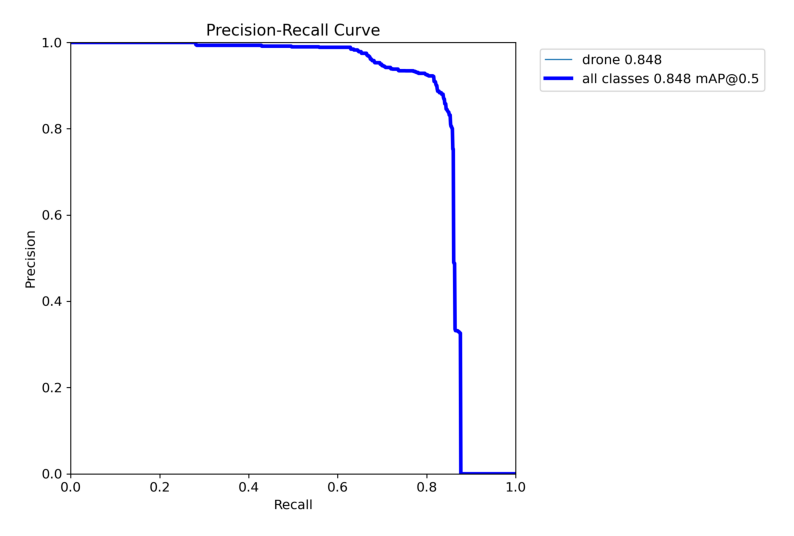

Saved: /content/drive/MyDrive/YOLO_Models/paper_final_figures/precision_recall_curve.png


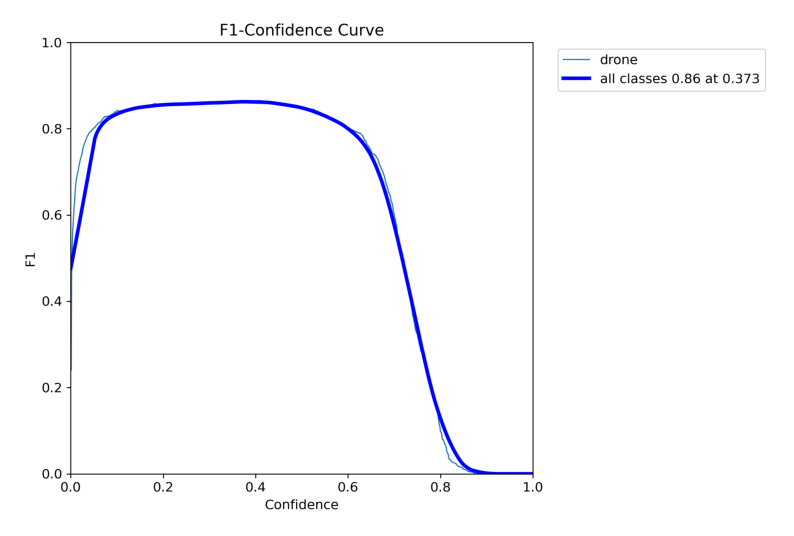

Saved: /content/drive/MyDrive/YOLO_Models/paper_final_figures/f1_curve.png


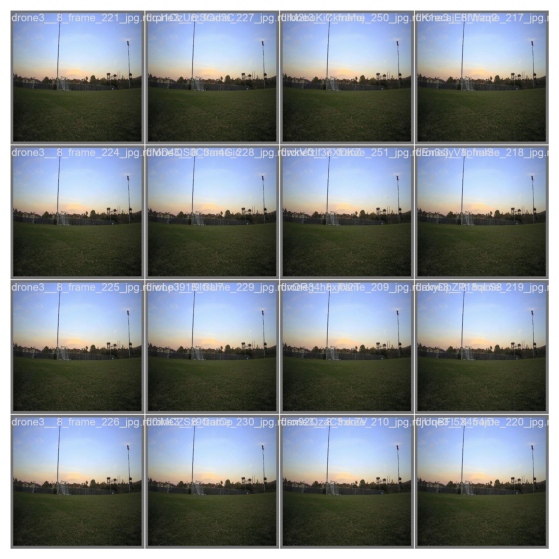

Saved: /content/drive/MyDrive/YOLO_Models/paper_final_figures/sample_predictions.png

=== YOLO results.csv columns ===
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

=== Final epoch metrics ===


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
36,37,5228.98,1.26589,0.53931,0.86987,0.90382,0.79088,0.82581,0.42227,1.42922,0.708,0.70945,0.000189,0.000189,0.000189


Saved: /content/drive/MyDrive/YOLO_Models/paper_final_figures/final_detection_metrics.csv

=== Tracking Files Found ===
Missing tracking_log or frame_summary CSV. Check TRACK_DIR.

=== Sample Tracked Frames ===
Found: 0


In [107]:
import os, glob
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# =========================
# PATHS
# =========================
YOLO_RUN_DIR = "/content/drive/MyDrive/YOLO_Models/uav_yolov8n_ep50_optimized/train_results"
TRACK_DIR = "/content/drive/MyDrive/uav_project/tracker_output_drone3_final"

PAPER_OUT = "/content/drive/MyDrive/YOLO_Models/paper_final_figures"

os.makedirs(PAPER_OUT, exist_ok=True)

def show_and_save_existing(src_path, new_name):
    if not os.path.exists(src_path):
        print(f"Missing: {src_path}")
        return None

    img = Image.open(src_path)
    plt.figure(figsize=(10, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    out_path = os.path.join(PAPER_OUT, new_name)
    img.save(out_path)
    print("Saved:", out_path)
    return out_path


# =========================
# 1) DETECTION TEST RESULTS
# =========================

detection_files = {
    "training_curves.png": "results.png",
    "confusion_matrix.png": "confusion_matrix.png",
    "confusion_matrix_normalized.png": "confusion_matrix_normalized.png",
    "precision_recall_curve.png": "BoxPR_curve.png",
    "f1_curve.png": "BoxF1_curve.png",
    "sample_predictions.png": "val_batch1_pred.jpg",
}

print("=== Detection Figures ===")
for new_name, file_name in detection_files.items():
    show_and_save_existing(os.path.join(YOLO_RUN_DIR, file_name), new_name)


# =========================
# 2) READ YOLO METRICS CSV
# =========================

results_csv = os.path.join(YOLO_RUN_DIR, "results.csv")

if os.path.exists(results_csv):
    results_df = pd.read_csv(results_csv)
    results_df.columns = results_df.columns.str.strip()

    print("\n=== YOLO results.csv columns ===")
    print(results_df.columns.tolist())

    print("\n=== Final epoch metrics ===")
    display(results_df.tail(1))

    # Save final metrics
    final_metrics_path = os.path.join(PAPER_OUT, "final_detection_metrics.csv")
    results_df.tail(1).to_csv(final_metrics_path, index=False)
    print("Saved:", final_metrics_path)
else:
    print("Missing results.csv:", results_csv)


# =========================
# 3) TRACKING RESULTS
# =========================

print("\n=== Tracking Files Found ===")
tracking_csvs = glob.glob(os.path.join(TRACK_DIR, "*.csv"))
for f in tracking_csvs:
    print(f)

tracking_log_candidates = glob.glob(os.path.join(TRACK_DIR, "tracking_log*.csv"))
frame_summary_candidates = glob.glob(os.path.join(TRACK_DIR, "frame_summary*.csv"))
tracking_summary_candidates = glob.glob(os.path.join(TRACK_DIR, "tracking_summary*.csv"))

tracking_log_path = tracking_log_candidates[0] if tracking_log_candidates else None
frame_summary_path = frame_summary_candidates[0] if frame_summary_candidates else None
tracking_summary_path = tracking_summary_candidates[0] if tracking_summary_candidates else None

if tracking_summary_path:
    print("\n=== Tracking Summary ===")
    tracking_summary_df = pd.read_csv(tracking_summary_path)
    display(tracking_summary_df)

    tracking_summary_out = os.path.join(PAPER_OUT, "tracking_summary.csv")
    tracking_summary_df.to_csv(tracking_summary_out, index=False)
    print("Saved:", tracking_summary_out)

if tracking_log_path and frame_summary_path:
    tracking_df = pd.read_csv(tracking_log_path)
    frame_summary_df = pd.read_csv(frame_summary_path)

    # Plot 1: Active tracks per frame
    plt.figure(figsize=(10, 5))
    plt.plot(frame_summary_df["frame_idx"], frame_summary_df["num_active_tracks"], linewidth=2)
    plt.xlabel("Frame")
    plt.ylabel("Number of Active Tracks")
    plt.title("Active UAV Tracks per Frame")
    plt.grid(alpha=0.3)
    out = os.path.join(PAPER_OUT, "tracking_active_tracks_per_frame.png")
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out)

    if not tracking_df.empty:
        # Plot 2: Track length distribution
        track_lengths = tracking_df.groupby("track_id")["frame_idx"].nunique()

        plt.figure(figsize=(8, 5))
        plt.bar(track_lengths.index.astype(str), track_lengths.values)
        plt.xlabel("Track ID")
        plt.ylabel("Track Length (frames)")
        plt.title("Track Length per UAV ID")
        plt.grid(axis="y", alpha=0.3)
        out = os.path.join(PAPER_OUT, "tracking_track_lengths.png")
        plt.savefig(out, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", out)

        # Plot 3: Trajectory visualization
        plt.figure(figsize=(8, 6))
        for tid, group in tracking_df.groupby("track_id"):
            plt.plot(group["cx"], group["cy"], marker="o", markersize=2, linewidth=1.5, label=f"ID {tid}")

        plt.gca().invert_yaxis()
        plt.xlabel("X pixel")
        plt.ylabel("Y pixel")
        plt.title("UAV Trajectory Visualization")
        plt.legend()
        plt.grid(alpha=0.3)
        out = os.path.join(PAPER_OUT, "tracking_trajectory_visualization.png")
        plt.savefig(out, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", out)

else:
    print("Missing tracking_log or frame_summary CSV. Check TRACK_DIR.")


# =========================
# 4) SAVE BEST TRACKED FRAMES
# =========================

tracked_frames = sorted(glob.glob(os.path.join(TRACK_DIR, "frame_*.jpg")))

print("\n=== Sample Tracked Frames ===")
print("Found:", len(tracked_frames))

# Pick 2 sample frames: middle and late
if tracked_frames:
    picks = []
    picks.append(tracked_frames[len(tracked_frames)//2])
    picks.append(tracked_frames[-1])

    for i, p in enumerate(picks, 1):
        show_and_save_existing(p, f"tracking_sample_frame_{i}.jpg")

---
# 17. Optional: Single-Image Inference


In [25]:
# ─────────────────────────────────────────────
from IPython.display import Image as IPImage
import cv2, os

def infer_single_image(img_path: str):
    """Run detection on a single image using the already loaded model."""

    frame = cv2.imread(img_path)

    if frame is None:
        print(f"Cannot read: {img_path}")
        return

    # Use already loaded model (DO NOT reload)
    results = model(frame, conf=0.35, verbose=False)[0]

    vis = results.plot()

    out_path = os.path.join(WORK_DIR, "single_infer.jpg")
    cv2.imwrite(out_path, vis)

    print(f"Saved: {out_path}")

    return IPImage(filename=out_path, width=700)

Results saved to /content/uav_project/test_predictions_final
692 labels saved to /content/uav_project/test_predictions_final/labels
Saved: /content/uav_project/single_infer.jpg


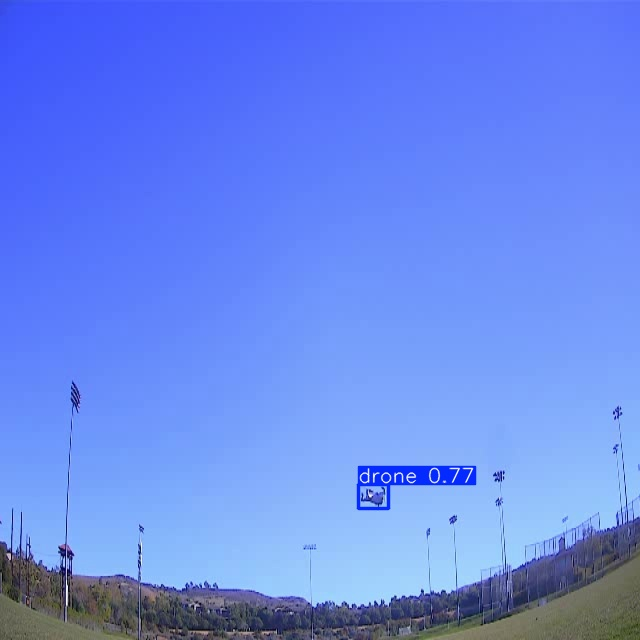

In [26]:
import glob

sample_img = sorted(
    glob.glob("/content/drive/MyDrive/New_Global_Split_v2/test/images/*.jpg")
)[0]

infer_single_image(sample_img)

---
# 18. Optional: Detector on an Unseen Video


In [69]:
from ultralytics import YOLO
import os

VIDEO_PATH = "/content/drone4_test_video.mp4"

OUTPUT_DIR = os.path.join(WORK_DIR, "unseen_video_test")

model.predict(
    source=VIDEO_PATH,
    conf=0.45,
    iou=0.45,
    imgsz=640,
    device=device,
    save=True,
    project=WORK_DIR,
    name="unseen_video_clean",
    exist_ok=True,
    verbose=False
)

print("Unseen video inference done")

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /content/uav_project/unseen_video_clean
267 labels saved to /content/uav_project/unseen_video_clean/labels
Unseen video inference done


In [28]:
!ffmpeg -i /content/uav_project/unseen_video_clean/drone4_test_video.avi \
        /content/uav_project/unseen_video_clean/drone4_test_video.mp4 -y

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [29]:
display(Video("/content/uav_project/unseen_video_clean/drone4_test_video.mp4", width=700))

---
# 19. Optional: Detector + Tracker on an Unseen Video


In [30]:
import os, cv2, time, shutil
import pandas as pd
from pathlib import Path
from collections import defaultdict

# ====== PATHS ======
BEST_PT = "/content/drive/MyDrive/YOLO_Models/uav_yolov8n_ep50_optimized/best.pt"

UNSEEN_VIDEO = "/content/drone4_test_video.mp4"  # CHANGE THIS
OUT_DIR = "/content/unseen_video_tracking_results"

os.makedirs(OUT_DIR, exist_ok=True)

TRACKED_VIDEO_OUT = os.path.join(OUT_DIR, "unseen_tracked_output.mp4")
TRACKING_CSV_OUT = os.path.join(OUT_DIR, "unseen_tracking_log.csv")
SUMMARY_CSV_OUT = os.path.join(OUT_DIR, "unseen_tracking_summary.csv")

In [31]:
# ====== RUN DETECTION + TRACKING ON UNSEEN VIDEO ======

cap = cv2.VideoCapture(UNSEEN_VIDEO)

if not cap.isOpened():
    raise ValueError(f"Cannot open video: {UNSEEN_VIDEO}")

video_fps = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("Video FPS:", video_fps)
print("Resolution:", width, "x", height)
print("Total frames:", total_frames)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(TRACKED_VIDEO_OUT, fourcc, video_fps, (width, height))

tracker = UAVTracker(
    det_model_path=BEST_PT,
    conf_threshold=0.38,
    iou_threshold=0.45,
    max_age=40,
    min_hits=5,
    iou_assoc_thr=0.30,
    distance_weight=0.40,
    max_center_dist=80.0,
    device=device,
)

tracking_rows = []
frame_summary_rows = []

start_time = time.time()
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    tracks = tracker.update(frame)

    vis = draw_tracks(frame, tracks, CLASS_NAMES)
    writer.write(vis)

    for t in tracks:
        x1, y1, x2, y2 = t["bbox_xyxy"]
        vx, vy = t["velocity"]

        tracking_rows.append({
            "frame_idx": frame_idx,
            "track_id": int(t["id"]),
            "class_id": int(t["class_id"]),
            "class_name": CLASS_NAMES.get(int(t["class_id"]), "unknown"),
            "x1": float(x1),
            "y1": float(y1),
            "x2": float(x2),
            "y2": float(y2),
            "cx": float((x1 + x2) / 2),
            "cy": float((y1 + y2) / 2),
            "w": float(x2 - x1),
            "h": float(y2 - y1),
            "track_conf_proxy": float(t["conf"]),
            "hits": int(t["hits"]),
            "vx": float(vx),
            "vy": float(vy),
            "speed_px_per_frame": float((vx**2 + vy**2) ** 0.5),
        })

    frame_summary_rows.append({
        "frame_idx": frame_idx,
        "num_active_tracks": len(tracks),
    })

    if frame_idx % 50 == 0:
        print(f"Processed frame {frame_idx}/{total_frames} | active tracks: {len(tracks)}")

    frame_idx += 1

cap.release()
writer.release()

elapsed = time.time() - start_time
tracking_fps = frame_idx / elapsed if elapsed > 0 else 0

tracking_df = pd.DataFrame(tracking_rows)
frame_summary_df = pd.DataFrame(frame_summary_rows)

tracking_df.to_csv(TRACKING_CSV_OUT, index=False)

print("\nDone.")
print("Tracked video saved:", TRACKED_VIDEO_OUT)
print("Tracking log saved:", TRACKING_CSV_OUT)
print("Processing FPS:", round(tracking_fps, 2))

Video FPS: 30.0
Resolution: 640 x 640
Total frames: 300
Processed frame 0/300 | active tracks: 1
Processed frame 50/300 | active tracks: 2
Processed frame 100/300 | active tracks: 2
Processed frame 150/300 | active tracks: 1
Processed frame 200/300 | active tracks: 1
Processed frame 250/300 | active tracks: 1

Done.
Tracked video saved: /content/unseen_video_tracking_results/unseen_tracked_output.mp4
Tracking log saved: /content/unseen_video_tracking_results/unseen_tracking_log.csv
Processing FPS: 4.33


In [32]:
# ====== SUMMARY METRICS ======

if tracking_df.empty:
    summary = {
        "video": os.path.basename(UNSEEN_VIDEO),
        "total_frames": frame_idx,
        "frames_with_tracks": 0,
        "total_unique_tracks": 0,
        "average_track_length_frames": 0,
        "longest_track_frames": 0,
        "average_active_tracks_per_frame": frame_summary_df["num_active_tracks"].mean(),
        "processing_fps": tracking_fps,
    }
else:
    track_lengths = tracking_df.groupby("track_id")["frame_idx"].nunique()

    summary = {
        "video": os.path.basename(UNSEEN_VIDEO),
        "total_frames": frame_idx,
        "frames_with_tracks": int(tracking_df["frame_idx"].nunique()),
        "total_unique_tracks": int(tracking_df["track_id"].nunique()),
        "average_track_length_frames": float(track_lengths.mean()),
        "longest_track_frames": int(track_lengths.max()),
        "shortest_track_frames": int(track_lengths.min()),
        "average_active_tracks_per_frame": float(frame_summary_df["num_active_tracks"].mean()),
        "max_active_tracks_per_frame": int(frame_summary_df["num_active_tracks"].max()),
        "mean_speed_px_per_frame": float(tracking_df["speed_px_per_frame"].mean()),
        "max_speed_px_per_frame": float(tracking_df["speed_px_per_frame"].max()),
        "processing_fps": float(tracking_fps),
    }

summary_df = pd.DataFrame([summary])
summary_df.to_csv(SUMMARY_CSV_OUT, index=False)

display(summary_df)
print("Summary saved:", SUMMARY_CSV_OUT)

,video,total_frames,frames_with_tracks,total_unique_tracks,average_track_length_frames,longest_track_frames,shortest_track_frames,average_active_tracks_per_frame,max_active_tracks_per_frame,mean_speed_px_per_frame,max_speed_px_per_frame,processing_fps
0,drone4_test_video.mp4,300,300,3,124.0,203,68,1.24,2,3.735752,7.736546,4.329108


Summary saved: /content/unseen_video_tracking_results/unseen_tracking_summary.csv


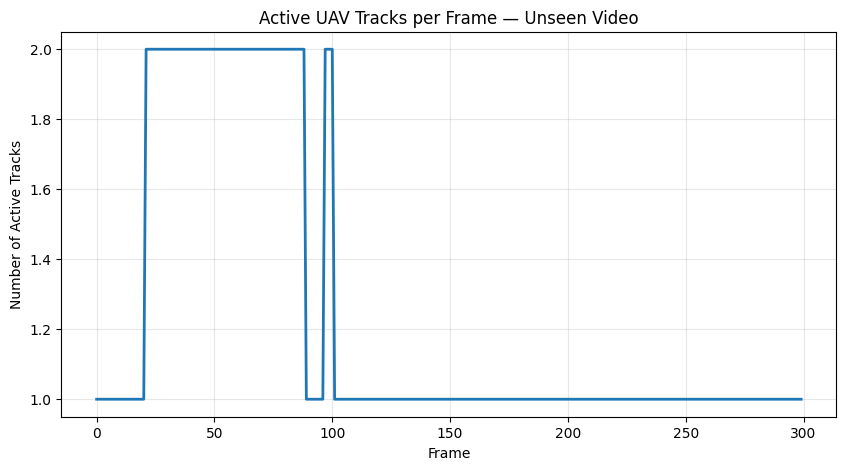

Saved: /content/unseen_video_tracking_results/unseen_active_tracks_per_frame.png


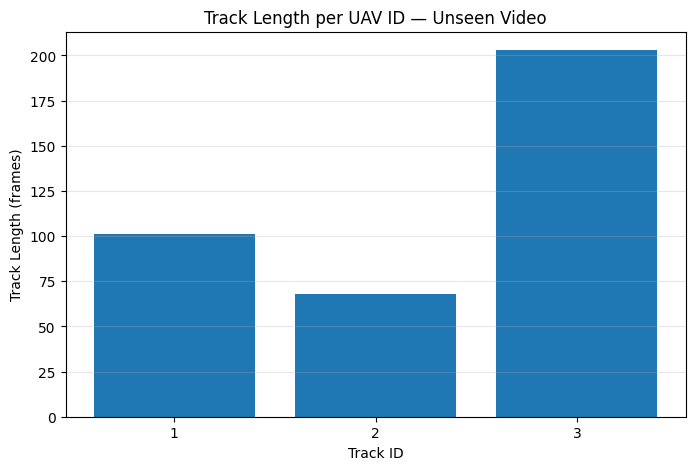

Saved: /content/unseen_video_tracking_results/unseen_track_lengths.png


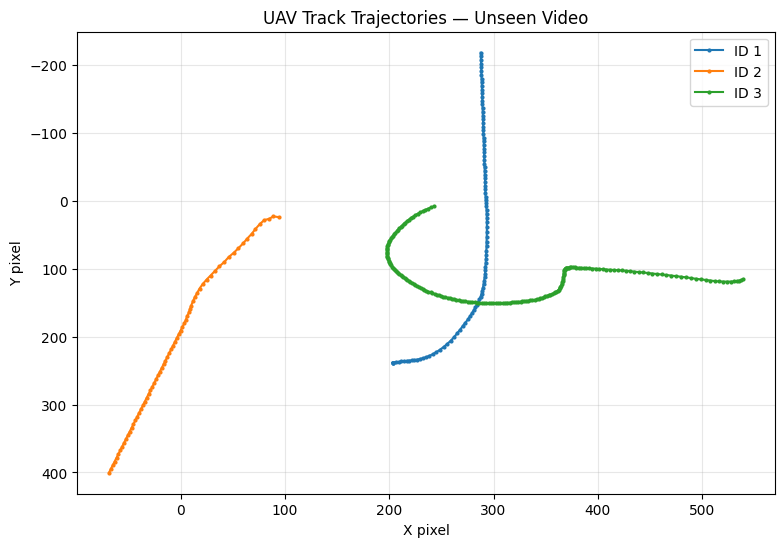

Saved: /content/unseen_video_tracking_results/unseen_trajectory_plot.png


In [33]:
# ====== PLOTS FOR UNSEEN VIDEO ======

import matplotlib.pyplot as plt

# Active tracks per frame
plt.figure(figsize=(10, 5))
plt.plot(frame_summary_df["frame_idx"], frame_summary_df["num_active_tracks"], linewidth=2)
plt.xlabel("Frame")
plt.ylabel("Number of Active Tracks")
plt.title("Active UAV Tracks per Frame — Unseen Video")
plt.grid(alpha=0.3)
active_plot = os.path.join(OUT_DIR, "unseen_active_tracks_per_frame.png")
plt.savefig(active_plot, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", active_plot)

# Track length plot
if not tracking_df.empty:
    track_lengths = tracking_df.groupby("track_id")["frame_idx"].nunique()

    plt.figure(figsize=(8, 5))
    plt.bar(track_lengths.index.astype(str), track_lengths.values)
    plt.xlabel("Track ID")
    plt.ylabel("Track Length (frames)")
    plt.title("Track Length per UAV ID — Unseen Video")
    plt.grid(axis="y", alpha=0.3)
    length_plot = os.path.join(OUT_DIR, "unseen_track_lengths.png")
    plt.savefig(length_plot, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", length_plot)

# Trajectory plot
if not tracking_df.empty:
    plt.figure(figsize=(9, 6))
    for tid, group in tracking_df.groupby("track_id"):
        plt.plot(group["cx"], group["cy"], marker="o", markersize=2, linewidth=1.5, label=f"ID {tid}")

    plt.gca().invert_yaxis()
    plt.xlabel("X pixel")
    plt.ylabel("Y pixel")
    plt.title("UAV Track Trajectories — Unseen Video")
    plt.legend()
    plt.grid(alpha=0.3)
    traj_plot = os.path.join(OUT_DIR, "unseen_trajectory_plot.png")
    plt.savefig(traj_plot, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", traj_plot)

### Optional rerun cell
Run this only if `NEW_OUTPUT_DIR` is already defined in your runtime.


In [34]:
tracking_summary_df = summarize_tracking(
    tracking_df,
    frame_summary_df,
    tracking_fps,
    NEW_OUTPUT_DIR,
    use_drone="unseen"
)

NameError: name 'NEW_OUTPUT_DIR' is not defined